# Phase-Aware Motion CV Log

Build a simple CV log for a video run:

- `data_present`: whether there is video covering the time interval.
- `valid_cycles`: whether phase awareness found cyclic machine motion.
- `state`: missing video, present but no valid cycles, or typical cyclic motion.
- `stoppage_context_clip_path`: optional `-5s/+5s` clip around present-but-no-cycle detections.

The notebook first detects the expected cycle profile from `measurements/reference_clip`, then uses that reference profile for local workflow checks and S3 processing. Do not use `stoppage_detection/stop_clips` as the local phase test source because those clips are already stopped and have no valid phase cycle.

The filename timestamp is treated as the video start time. The probed duration gives the video end time. If there is a gap after a video ends, the notebook marks that gap as `camera_off_after_motion_stop` because this camera turns off shortly after motion stops.


## 1. Imports

In [11]:
from __future__ import annotations

from pathlib import Path
import re
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Make VideoModule importable whether the notebook is launched from the repo root,
# this folder, or the parent workspace folder.
current_dir = Path.cwd()
candidate_roots = [
    current_dir,
    current_dir / "24H_Insights",
    current_dir.parent,
    current_dir.parent / "24H_Insights",
]
repo_root = next((path for path in candidate_roots if (path / "VideoModule").exists()), None)
if repo_root is None:
    raise RuntimeError("Could not find repo root containing VideoModule.")

repo_root = repo_root.resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from VideoModule.data_classes.phase.cfg import PhaseDetectionConfig
from VideoModule.io.read import probe_video, read_video, read_video_range
from VideoModule.io.write import write_video
from VideoModule.phase_detection import run_phase_awareness

## 2. Configuration

The reference clip is the baseline for expected cycle timing. The local folder test defaults to that same reference clip so the notebook workflow can be checked before S3 is used on real production data.

Only point `source_video_dir` at another local folder when those clips contain normal cyclic motion. Stop-context clips are useful outputs, but they are not a valid phase-detection test set.


In [12]:
# Resolve paths from the repo root found in the import cell.
notebook_dir = repo_root / "video_coverage_log"
if not notebook_dir.exists():
    raise RuntimeError(f"Could not find video_coverage_log folder under: {repo_root}")

# Reference clip used to establish the expected machine cycle profile.
reference_clip_dir = repo_root / "measurements" / "reference_clip"

# Local workflow test input. Keep this on the reference clip unless the folder contains normal cyclic motion.
source_video_dir = reference_clip_dir

# Output folders.
output_dir = notebook_dir / "phase_aware_motion_cv_log_output"
context_clip_dir = output_dir / "stoppage_context_clips"
reference_test_dir = output_dir / "reference_clip_test"
s3_run_dir = output_dir / "s3_run"
plot_dir = output_dir / "plots"

# Create output folders before writing any artefacts.
output_dir.mkdir(parents=True, exist_ok=True)
context_clip_dir.mkdir(parents=True, exist_ok=True)
reference_test_dir.mkdir(parents=True, exist_ok=True)
s3_run_dir.mkdir(parents=True, exist_ok=True)
plot_dir.mkdir(parents=True, exist_ok=True)

# Optional expected run window. Use strings like "2026-06-25_17-00-00".
expected_start_time = None
expected_end_time = None
expected_window_minutes = 60

# Video discovery and phase detection settings.
video_extensions = {".mp4", ".mov", ".avi", ".mkv", ".ts", ".m4v"}
max_videos = None  # Set to a small integer while testing.
phase_max_frames = 2000  # Match the measurement notebook; use None to decode full clips.
min_valid_cycles = 2
reference_frequency_tolerance_fraction = 0.35
camera_off_gap_grace_seconds = 20.0

# Stoppage context export settings.
context_seconds_before = 5.0
context_seconds_after = 5.0
export_stoppage_context_clips = True

# Phase awareness config. Keep this aligned with the measurement notebook for this camera.
phase_config = PhaseDetectionConfig(
    energy_method="ncc",
    use_fcwt=True,
    min_hz=0.2,
    max_hz=2.0,
    min_region_seconds=1.0,
    min_freq_change_hz=0.1,
    num_phases=10,
    phase_binning="linear_time",
)

print(f"Repo root: {repo_root}")
print(f"Reference clip folder: {reference_clip_dir}")
print(f"Source videos: {source_video_dir}")
print(f"Outputs: {output_dir}")


Repo root: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights
Reference clip folder: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\measurements\reference_clip
Source videos: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\measurements\reference_clip
Outputs: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output


## 3. Helpers

These helpers keep notebook cells readable. `VideoModule` still owns the video read/probe/write and phase-awareness work.

In [13]:
timestamp_pattern = re.compile(r"(20\d{2}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})")


def parse_video_start_time(video_path: Path) -> pd.Timestamp | None:
    """Read the first timestamp-like value from a video filename."""
    match = timestamp_pattern.search(video_path.name)
    if match is None:
        return None
    return pd.to_datetime(match.group(1), format="%Y-%m-%d_%H-%M-%S")


def format_log_time(value: pd.Timestamp) -> str:
    """Use the same timestamp format as the existing coverage log."""
    return value.strftime("%Y-%m-%d_%H-%M-%S")


def list_video_paths(folder: Path) -> list[Path]:
    """Find videos under the source folder in timestamp/name order."""
    if not folder.exists():
        raise FileNotFoundError(f"Video folder does not exist: {folder}")

    # Collect supported video files only.
    video_paths = [path for path in folder.rglob("*") if path.suffix.lower() in video_extensions]

    # Sort by parsed timestamp first, then by filename for stable output.
    video_paths.sort(key=lambda path: (parse_video_start_time(path) or pd.Timestamp.max, path.name))

    if max_videos is not None:
        video_paths = video_paths[:max_videos]

    return video_paths


def probe_video_safely(video_path: Path) -> dict:
    """Probe a video and return a consistent metadata dictionary."""
    try:
        info = probe_video(video_path)
        info["probe_error"] = ""
        return info
    except Exception as exc:
        return {
            "width": 0,
            "height": 0,
            "frames": 0,
            "fps": 0.0,
            "duration_s": 0.0,
            "size_bytes": 0,
            "probe_error": str(exc),
        }


def build_video_inventory(video_paths: list[Path]) -> pd.DataFrame:
    """Create one metadata row per discovered video."""
    rows = []

    for video_path in video_paths:
        # Start time comes from the filename, matching the existing VideoModule coverage-log convention.
        start_time = parse_video_start_time(video_path)

        # Probe video metadata without loading frames.
        info = probe_video_safely(video_path)
        duration_seconds = float(info.get("duration_s", 0.0) or 0.0)

        # End time is only meaningful when the filename has a timestamp.
        end_time = None
        if start_time is not None:
            end_time = start_time + pd.Timedelta(seconds=duration_seconds)

        rows.append({
            "video_path": video_path,
            "video_name": video_path.name,
            "start_time": start_time,
            "end_time": end_time,
            "duration_s": duration_seconds,
            "fps": float(info.get("fps", 0.0) or 0.0),
            "n_frames": int(info.get("frames", 0) or 0),
            "width": int(info.get("width", 0) or 0),
            "height": int(info.get("height", 0) or 0),
            "size_bytes": int(info.get("size_bytes", 0) or 0),
            "probe_error": info.get("probe_error", ""),
        })

    return pd.DataFrame(rows)


def build_expected_windows(video_df: pd.DataFrame) -> pd.DataFrame:
    """Build audit windows, either from user settings or directly from observed videos."""
    if expected_start_time is None or expected_end_time is None:
        # Without an expected run window, each timestamped video becomes its own interval.
        observed = video_df.dropna(subset=["start_time", "end_time"]).copy()
        return observed[["start_time", "end_time"]].reset_index(drop=True)

    # With an expected run window, create fixed-size intervals so missing video can be logged.
    start = pd.to_datetime(expected_start_time, format="%Y-%m-%d_%H-%M-%S")
    end = pd.to_datetime(expected_end_time, format="%Y-%m-%d_%H-%M-%S")
    if end <= start:
        raise ValueError("expected_end_time must be after expected_start_time")

    starts = pd.date_range(start=start, end=end, freq=f"{expected_window_minutes}min", inclusive="left")
    rows = []
    for window_start in starts:
        window_end = min(window_start + pd.Timedelta(minutes=expected_window_minutes), end)
        rows.append({"start_time": window_start, "end_time": window_end})
    return pd.DataFrame(rows)


def find_videos_for_window(video_df: pd.DataFrame, window_start: pd.Timestamp, window_end: pd.Timestamp) -> pd.DataFrame:
    """Return videos that overlap the requested time window."""
    usable = video_df.dropna(subset=["start_time", "end_time"]).copy()
    overlaps = (usable["start_time"] < window_end) & (usable["end_time"] > window_start)
    return usable.loc[overlaps].sort_values("start_time")


def empty_gap_context() -> dict:
    """Return blank columns used by inferred camera-off rows."""
    return {
        "inferred_stop_time": "",
        "previous_video_name": "",
        "next_video_name": "",
        "gap_seconds_after_previous_video": np.nan,
    }


def build_camera_off_gap_row(previous_row: pd.Series, next_row: pd.Series | None, gap_end: pd.Timestamp) -> dict:
    """Build one row for a gap after a video ends.

    The camera file timestamp is the start time. A gap after the probed end time is therefore
    interpreted as the camera turning off after motion stopped.
    """
    gap_start = pd.to_datetime(previous_row["end"], format="%Y-%m-%d_%H-%M-%S")
    gap_seconds = float((gap_end - gap_start).total_seconds())

    next_video_name = ""
    if next_row is not None:
        next_video_name = str(next_row.get("video_name", ""))

    return {
        "data_present": "n",
        "start": format_log_time(gap_start),
        "end": format_log_time(gap_end),
        "valid_cycles": "n",
        "state": "camera_off_after_motion_stop",
        "video_name": "",
        "video_path": "",
        "source": previous_row.get("source", ""),
        "status": "inferred_camera_off",
        "reason": (
            "camera off after previous video ended; "
            f"gap {gap_seconds:.1f}s exceeds {camera_off_gap_grace_seconds:.1f}s grace"
        ),
        "n_cycles": 0,
        "cycle_frequency_hz": np.nan,
        "mean_cycle_frames": np.nan,
        "cycle_cv": np.nan,
        **empty_reference_comparison(),
        "duration_s": gap_seconds,
        "fps": np.nan,
        "n_frames": 0,
        "detection_second": np.nan,
        "stoppage_context_clip_path": "",
        "phase_error": "",
        "inferred_stop_time": format_log_time(gap_start),
        "previous_video_name": previous_row.get("video_name", ""),
        "next_video_name": next_video_name,
        "gap_seconds_after_previous_video": gap_seconds,
    }


def add_camera_off_gap_rows(cv_log_df: pd.DataFrame, analysis_end_time: pd.Timestamp | None = None) -> pd.DataFrame:
    """Insert inferred camera-off rows between recorded videos when there is a real time gap."""
    if cv_log_df.empty:
        return cv_log_df

    # Rebuild from non-gap rows so repeated notebook runs do not duplicate inferred gaps.
    base_df = cv_log_df[cv_log_df["state"] != "camera_off_after_motion_stop"].copy()

    # Only recorded video rows can define a camera-off gap.
    video_df = base_df[base_df["data_present"] == "y"].copy()
    if video_df.empty:
        return base_df

    video_df["start_dt"] = pd.to_datetime(video_df["start"], format="%Y-%m-%d_%H-%M-%S")
    video_df["end_dt"] = pd.to_datetime(video_df["end"], format="%Y-%m-%d_%H-%M-%S")
    video_df = video_df.sort_values("start_dt").reset_index(drop=True)

    gap_rows = []
    for row_index in range(len(video_df) - 1):
        previous_row = video_df.iloc[row_index]
        next_row = video_df.iloc[row_index + 1]
        gap_start = previous_row["end_dt"]
        gap_end = next_row["start_dt"]
        gap_seconds = float((gap_end - gap_start).total_seconds())

        if gap_seconds > camera_off_gap_grace_seconds:
            gap_rows.append(build_camera_off_gap_row(previous_row, next_row, gap_end))

    if analysis_end_time is not None and len(video_df) > 0:
        last_row = video_df.iloc[-1]
        gap_start = last_row["end_dt"]
        gap_seconds = float((analysis_end_time - gap_start).total_seconds())
        if gap_seconds > camera_off_gap_grace_seconds:
            gap_rows.append(build_camera_off_gap_row(last_row, None, analysis_end_time))

    if not gap_rows:
        return base_df

    combined_df = pd.concat([base_df, pd.DataFrame(gap_rows)], ignore_index=True, sort=False)
    combined_df["sort_start_dt"] = pd.to_datetime(combined_df["start"], format="%Y-%m-%d_%H-%M-%S")
    combined_df = combined_df.sort_values(["sort_start_dt", "state"]).drop(columns=["sort_start_dt"])
    return combined_df.reset_index(drop=True)


## 4. Run Phase Awareness Per Video

The reference clip establishes the expected cycle count, cycle length, and cycle frequency. Each later video still runs `VideoModule.phase_detection.run_phase_awareness`; the reference metrics are recorded beside the result so mismatched phase timing is visible.


In [14]:
def summarise_cycles(cycles: list[tuple[int, int]], fps: float) -> dict:
    """Calculate simple cycle metrics for the CV log."""
    if len(cycles) == 0 or fps <= 0:
        return {
            "cycle_count": len(cycles),
            "cycle_frequency_hz": np.nan,
            "mean_cycle_frames": np.nan,
            "cycle_cv": np.nan,
        }

    # Convert detected cycle windows into cycle lengths.
    cycle_lengths = np.array([end - start for start, end in cycles], dtype=float)

    # Frequency is frame rate divided by mean frames per cycle.
    mean_cycle_frames = float(np.mean(cycle_lengths))
    cycle_frequency_hz = float(fps / mean_cycle_frames) if mean_cycle_frames > 0 else np.nan

    # CV gives a quick stability signal for the detected cycle lengths.
    cycle_cv = float(np.std(cycle_lengths) / (mean_cycle_frames + 1e-9))

    return {
        "cycle_count": len(cycles),
        "cycle_frequency_hz": cycle_frequency_hz,
        "mean_cycle_frames": mean_cycle_frames,
        "cycle_cv": cycle_cv,
    }


def empty_reference_comparison() -> dict:
    """Return blank reference-comparison fields for failed or missing rows."""
    return {
        "reference_cycle_count": np.nan,
        "reference_cycle_frequency_hz": np.nan,
        "reference_mean_cycle_frames": np.nan,
        "cycle_frequency_ratio_to_reference": np.nan,
        "matches_reference_frequency": "",
    }


def compare_to_reference_profile(cycle_summary: dict, reference_phase_profile: dict | None) -> dict:
    """Compare one video's detected cycle timing with the reference clip timing."""
    if reference_phase_profile is None:
        return empty_reference_comparison()

    reference_frequency_hz = float(reference_phase_profile.get("cycle_frequency_hz", np.nan))
    current_frequency_hz = float(cycle_summary.get("cycle_frequency_hz", np.nan))

    if pd.isna(reference_frequency_hz) or reference_frequency_hz <= 0 or pd.isna(current_frequency_hz):
        frequency_ratio = np.nan
        matches_reference_frequency = ""
    else:
        frequency_ratio = current_frequency_hz / reference_frequency_hz
        lower_bound = 1.0 - reference_frequency_tolerance_fraction
        upper_bound = 1.0 + reference_frequency_tolerance_fraction
        matches_reference_frequency = "y" if lower_bound <= frequency_ratio <= upper_bound else "n"

    return {
        "reference_cycle_count": int(reference_phase_profile.get("cycle_count", 0)),
        "reference_cycle_frequency_hz": reference_frequency_hz,
        "reference_mean_cycle_frames": reference_phase_profile.get("mean_cycle_frames", np.nan),
        "cycle_frequency_ratio_to_reference": frequency_ratio,
        "matches_reference_frequency": matches_reference_frequency,
    }


def estimate_stoppage_second(phase_result, duration_seconds: float) -> float:
    """Estimate where to centre the stoppage context clip."""
    energy = np.asarray(getattr(phase_result, "energy_signal", []), dtype=float)

    if len(energy) < 10:
        return max(0.0, duration_seconds / 2.0)

    # Low energy is the simplest proxy for a still or stopped section.
    threshold = float(np.nanpercentile(energy, 20))
    low_energy_indices = np.flatnonzero(energy <= threshold)

    if len(low_energy_indices) == 0:
        return max(0.0, duration_seconds / 2.0)

    # Use the first low-energy point as the context centre.
    fps = float(getattr(phase_result, "fps", 0.0) or 0.0)
    if fps <= 0:
        return max(0.0, duration_seconds / 2.0)

    return float(low_energy_indices[0] / fps)


def run_phase_check(video_path: Path, reference_phase_profile: dict | None = None) -> dict:
    """Run VideoModule phase awareness and return one result dictionary."""
    info = probe_video_safely(video_path)
    fps = float(info.get("fps", 0.0) or 0.0)
    frame_count = int(info.get("frames", 0) or 0)
    duration_seconds = float(info.get("duration_s", 0.0) or 0.0)

    if frame_count <= 0 or fps <= 0:
        return {
            "status": "failed",
            "reason": "video has no usable frames or fps",
            "valid_cycles": "n",
            "cycle_count": 0,
            "cycle_frequency_hz": np.nan,
            "mean_cycle_frames": np.nan,
            "cycle_cv": np.nan,
            "detection_second": np.nan,
            "phase_error": "",
            **empty_reference_comparison(),
        }

    try:
        # Decode with VideoModule. The optional cap keeps exploratory notebook runs manageable.
        frames, decoded_fps = read_video(video_path, max_frames=phase_max_frames)

        if len(frames) == 0:
            raise ValueError("read_video returned no frames")

        # Run the central phase-awareness component.
        phase_awareness = run_phase_awareness(frames=frames, fps=decoded_fps, config=phase_config)
        phase_result = phase_awareness.dyn
        cycles = list(phase_result.cycles)

        # Use a minimum cycle count as the valid-motion gate.
        valid_cycles = "y" if len(cycles) >= min_valid_cycles else "n"
        cycle_summary = summarise_cycles(cycles, decoded_fps)
        reference_comparison = compare_to_reference_profile(cycle_summary, reference_phase_profile)

        return {
            "status": "ok" if valid_cycles == "y" else "no_valid_cycles",
            "reason": "" if valid_cycles == "y" else f"found {len(cycles)} cycle(s), need {min_valid_cycles}",
            "valid_cycles": valid_cycles,
            "detection_second": estimate_stoppage_second(phase_result, duration_seconds),
            "phase_error": "",
            **cycle_summary,
            **reference_comparison,
        }

    except Exception as exc:
        return {
            "status": "failed",
            "reason": "phase awareness failed",
            "valid_cycles": "n",
            "cycle_count": 0,
            "cycle_frequency_hz": np.nan,
            "mean_cycle_frames": np.nan,
            "cycle_cv": np.nan,
            "detection_second": np.nan,
            "phase_error": str(exc),
            **empty_reference_comparison(),
        }


def build_reference_phase_profile(reference_video_path: Path) -> dict:
    """Detect the expected cycle timing from the normal reference clip."""
    reference_summary = run_phase_check(reference_video_path)

    if reference_summary["valid_cycles"] != "y":
        raise RuntimeError(
            "Reference clip did not produce valid cycles. "
            f"Status: {reference_summary['status']}. Reason: {reference_summary['reason']}. "
            f"Error: {reference_summary['phase_error']}"
        )

    return {
        "video_name": reference_video_path.name,
        "cycle_count": int(reference_summary["cycle_count"]),
        "cycle_frequency_hz": reference_summary["cycle_frequency_hz"],
        "mean_cycle_frames": reference_summary["mean_cycle_frames"],
        "cycle_cv": reference_summary["cycle_cv"],
    }


## 5. Shared Row Builder And Context Export

These helpers are used by the reference smoke test, the local-folder run, and the S3 run so all paths use the same phase-awareness decision rule.

In [15]:
def extract_context_clip(video_path: Path, centre_second: float, output_path: Path) -> str:
    """Extract a short context clip around a detection time."""
    info = probe_video_safely(video_path)
    fps = float(info.get("fps", 0.0) or 0.0)
    frame_count = int(info.get("frames", 0) or 0)

    if fps <= 0 or frame_count <= 0:
        return ""

    # Convert the requested time window into frame indices.
    start_second = max(0.0, centre_second - context_seconds_before)
    end_second = min(float(info.get("duration_s", 0.0) or 0.0), centre_second + context_seconds_after)
    start_frame = max(0, int(round(start_second * fps)))
    end_frame = min(frame_count - 1, int(round(end_second * fps)))

    if end_frame <= start_frame:
        return ""

    # Read only the requested range, then write it as a review clip.
    frames, decoded_fps = read_video_range(video_path, start_frame=start_frame, end_frame=end_frame)
    if len(frames) == 0:
        return ""

    output_path.parent.mkdir(parents=True, exist_ok=True)
    write_video(frames, output_path, fps=decoded_fps)
    return str(output_path)


def build_cv_log_row_for_video(
    video_path: Path,
    interval_start: pd.Timestamp,
    interval_end: pd.Timestamp,
    context_output_dir: Path,
    source_label: str,
    reference_phase_profile: dict | None = None,
) -> dict:
    """Process one video into the common CV-log row shape."""
    # Probe metadata first so failures still get useful context in the log.
    info = probe_video_safely(video_path)

    # Run the shared VideoModule phase-awareness check.
    phase_summary = run_phase_check(video_path, reference_phase_profile)
    valid_cycles = phase_summary["valid_cycles"]
    state = "typical_motion" if valid_cycles == "y" else "present_no_valid_cycles"

    # Build the base row before optional context export.
    row = {
        "data_present": "y",
        "start": format_log_time(interval_start),
        "end": format_log_time(interval_end),
        "valid_cycles": valid_cycles,
        "state": state,
        "video_name": video_path.name,
        "video_path": str(video_path),
        "source": source_label,
        "status": phase_summary["status"],
        "reason": phase_summary["reason"],
        "n_cycles": int(phase_summary["cycle_count"]),
        "cycle_frequency_hz": phase_summary["cycle_frequency_hz"],
        "mean_cycle_frames": phase_summary["mean_cycle_frames"],
        "cycle_cv": phase_summary["cycle_cv"],
        "reference_cycle_count": phase_summary["reference_cycle_count"],
        "reference_cycle_frequency_hz": phase_summary["reference_cycle_frequency_hz"],
        "reference_mean_cycle_frames": phase_summary["reference_mean_cycle_frames"],
        "cycle_frequency_ratio_to_reference": phase_summary["cycle_frequency_ratio_to_reference"],
        "matches_reference_frequency": phase_summary["matches_reference_frequency"],
        "duration_s": float(info.get("duration_s", 0.0) or 0.0),
        "fps": float(info.get("fps", 0.0) or 0.0),
        "n_frames": int(info.get("frames", 0) or 0),
        "detection_second": phase_summary["detection_second"],
        "stoppage_context_clip_path": "",
        "phase_error": phase_summary["phase_error"],
        **empty_gap_context(),
    }

    # Export the same -5s/+5s context clip rule for any present-but-no-cycle video.
    if export_stoppage_context_clips and valid_cycles == "n" and row["duration_s"] > 0:
        detection_second = row["detection_second"]
        if pd.isna(detection_second):
            detection_second = row["duration_s"] / 2.0

        output_name = f"{video_path.stem}__context.mp4"
        output_path = context_output_dir / output_name
        row["stoppage_context_clip_path"] = extract_context_clip(video_path, float(detection_second), output_path)

    return row


def append_dataframe_rows(dataframe: pd.DataFrame, csv_path: Path) -> None:
    """Append rows to a CSV while preserving any existing columns."""
    if dataframe.empty:
        return

    csv_path.parent.mkdir(parents=True, exist_ok=True)
    if not csv_path.exists() or csv_path.stat().st_size == 0:
        dataframe.to_csv(csv_path, index=False)
        return

    # Existing files may have a smaller column set from an earlier run.
    existing_df = pd.read_csv(csv_path)
    all_columns = list(existing_df.columns)
    for column_name in dataframe.columns:
        if column_name not in all_columns:
            all_columns.append(column_name)

    combined_df = pd.concat(
        [existing_df.reindex(columns=all_columns), dataframe.reindex(columns=all_columns)],
        ignore_index=True,
    )
    combined_df.to_csv(csv_path, index=False)


## 6. Reference Clip Baseline And Smoke Test

Detect the expected cycle profile from the normal reference clip, then run the normal CV-log row builder against that same clip. This verifies the rest of the workflow before local or S3 batch processing.


In [16]:
reference_video_paths = list_video_paths(reference_clip_dir)
if not reference_video_paths:
    raise FileNotFoundError(f"No reference clip was found in: {reference_clip_dir}")

reference_video_path = reference_video_paths[0]
reference_info = probe_video_safely(reference_video_path)
reference_start_time = parse_video_start_time(reference_video_path)

# Some reference clips may not include a parseable timestamp. Use a stable placeholder if needed.
if reference_start_time is None:
    reference_start_time = pd.Timestamp("1970-01-01 00:00:00")

reference_end_time = reference_start_time + pd.Timedelta(seconds=float(reference_info.get("duration_s", 0.0) or 0.0))
reference_phase_profile = build_reference_phase_profile(reference_video_path)
print("Reference phase profile:")
print(reference_phase_profile)

reference_context_dir = reference_test_dir / "context_clips"
reference_row = build_cv_log_row_for_video(
    video_path=reference_video_path,
    interval_start=reference_start_time,
    interval_end=reference_end_time,
    context_output_dir=reference_context_dir,
    source_label="reference_clip",
    reference_phase_profile=reference_phase_profile,
)

reference_test_df = pd.DataFrame([reference_row])
reference_test_path = reference_test_dir / "reference_clip_cv_test.csv"
reference_test_df.to_csv(reference_test_path, index=False)

display(reference_test_df)
print(f"Reference clip test written to: {reference_test_path}")


C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\VideoModule\phase_detection\dynamic_phase_detection.py:1435: UserWarning: fCWT not available, using PyWavelets CWT (slower). For better performance, install fCWT: pip install fcwt
  span_regions, span_time, method = detect_frequency_regions_fcwt(


Reference phase profile:
{'video_name': 'cortexvpu-01a-005-41884872_2026-06-19_03-55-24_933414.ts', 'cycle_count': 5, 'cycle_frequency_hz': 0.5675655222864062, 'mean_cycle_frames': 273.4, 'cycle_cv': 0.0017918725258041107}


,data_present,start,end,valid_cycles,state,video_name,video_path,source,status,reason,...,duration_s,fps,n_frames,detection_second,stoppage_context_clip_path,phase_error,inferred_stop_time,previous_video_name,next_video_name,gap_seconds_after_previous_video
0,y,2026-06-19_03-55-24,2026-06-19_03-56-35,y,typical_motion,cortexvpu-01a-005-41884872_2026-06-19_03-55-24...,C:\Users\TimKitchen\OneDrive\OneDrive - Purple...,reference_clip,ok,,...,71.881333,155.172414,11154,1.044,,,,,,NaN


Reference clip test written to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\reference_clip_test\reference_clip_cv_test.csv


## 7. Build Local Folder CV Log

This creates the core table:

`data_present, start, end, valid_cycles`

By default this section runs against `measurements/reference_clip` so it checks the workflow on known cyclic data. Change `source_video_dir` only for local clips that should contain normal phase cycles.


In [17]:
video_paths = list_video_paths(source_video_dir)
video_inventory_df = build_video_inventory(video_paths)
expected_windows_df = build_expected_windows(video_inventory_df)

display(video_inventory_df.head())
print(f"Discovered videos: {len(video_inventory_df)}")
print(f"Audit windows: {len(expected_windows_df)}")


,video_path,video_name,start_time,end_time,duration_s,fps,n_frames,width,height,size_bytes,probe_error
0,C:\Users\TimKitchen\OneDrive\OneDrive - Purple...,cortexvpu-01a-005-41884872_2026-06-19_03-55-24...,2026-06-19 03:55:24,2026-06-19 03:56:35.881333333,71.881333,155.172414,11154,1920,1000,75000156,


Discovered videos: 1
Audit windows: 1


In [18]:
cv_log_rows = []
phase_cache = {}

for _, window in expected_windows_df.iterrows():
    window_start = window["start_time"]
    window_end = window["end_time"]
    matching_videos = find_videos_for_window(video_inventory_df, window_start, window_end)

    if matching_videos.empty:
        # Missing video is a real CV-log state.
        cv_log_rows.append({
            "data_present": "n",
            "start": format_log_time(window_start),
            "end": format_log_time(window_end),
            "valid_cycles": "n",
            "state": "missing_video",
            "video_name": "",
            "video_path": "",
            "status": "missing",
            "reason": "no recording in window",
            "n_cycles": 0,
            "cycle_frequency_hz": np.nan,
            "mean_cycle_frames": np.nan,
            "cycle_cv": np.nan,
            **empty_reference_comparison(),
            "duration_s": float((window_end - window_start).total_seconds()),
            "fps": np.nan,
            "n_frames": 0,
            "detection_second": np.nan,
            "stoppage_context_clip_path": "",
            "phase_error": "",
            **empty_gap_context(),
        })
        continue

    # Use the first overlapping video for this window.
    # If hourly windows contain multiple files, each can be audited by leaving expected times as None.
    video_row = matching_videos.iloc[0]
    video_path = Path(video_row["video_path"])

    if video_path not in phase_cache:
        phase_cache[video_path] = run_phase_check(video_path, reference_phase_profile)

    phase_summary = phase_cache[video_path]
    valid_cycles = phase_summary["valid_cycles"]
    state = "typical_motion" if valid_cycles == "y" else "present_no_valid_cycles"

    cv_log_rows.append({
        "data_present": "y",
        "start": format_log_time(window_start),
        "end": format_log_time(window_end),
        "valid_cycles": valid_cycles,
        "state": state,
        "video_name": video_row["video_name"],
        "video_path": str(video_path),
        "status": phase_summary["status"],
        "reason": phase_summary["reason"],
        "n_cycles": int(phase_summary["cycle_count"]),
        "cycle_frequency_hz": phase_summary["cycle_frequency_hz"],
        "mean_cycle_frames": phase_summary["mean_cycle_frames"],
        "cycle_cv": phase_summary["cycle_cv"],
        "reference_cycle_count": phase_summary["reference_cycle_count"],
        "reference_cycle_frequency_hz": phase_summary["reference_cycle_frequency_hz"],
        "reference_mean_cycle_frames": phase_summary["reference_mean_cycle_frames"],
        "cycle_frequency_ratio_to_reference": phase_summary["cycle_frequency_ratio_to_reference"],
        "matches_reference_frequency": phase_summary["matches_reference_frequency"],
        "duration_s": float(video_row["duration_s"]),
        "fps": float(video_row["fps"]),
        "n_frames": int(video_row["n_frames"]),
        "detection_second": phase_summary["detection_second"],
        "stoppage_context_clip_path": "",
        "phase_error": phase_summary["phase_error"],
        **empty_gap_context(),
    })

cv_log_df = pd.DataFrame(cv_log_rows)
local_analysis_end_time = None
if expected_end_time is not None:
    local_analysis_end_time = pd.to_datetime(expected_end_time, format="%Y-%m-%d_%H-%M-%S")
cv_log_df = add_camera_off_gap_rows(cv_log_df, local_analysis_end_time)
cv_log_path = output_dir / "cv_motion_log.csv"
cv_log_df.to_csv(cv_log_path, index=False)

display(cv_log_df)
print(f"CV log written to: {cv_log_path}")


C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\VideoModule\phase_detection\dynamic_phase_detection.py:1435: UserWarning: fCWT not available, using PyWavelets CWT (slower). For better performance, install fCWT: pip install fcwt
  span_regions, span_time, method = detect_frequency_regions_fcwt(


,data_present,start,end,valid_cycles,state,video_name,video_path,status,reason,n_cycles,...,duration_s,fps,n_frames,detection_second,stoppage_context_clip_path,phase_error,inferred_stop_time,previous_video_name,next_video_name,gap_seconds_after_previous_video
0,y,2026-06-19_03-55-24,2026-06-19_03-56-35,y,typical_motion,cortexvpu-01a-005-41884872_2026-06-19_03-55-24...,C:\Users\TimKitchen\OneDrive\OneDrive - Purple...,ok,,5,...,71.881333,155.172414,11154,1.044,,,,,,NaN


CV log written to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\cv_motion_log.csv


## 8. Split Typical Motion And Stoppages

`typical_motion_df` is video-present and cyclic.

`stoppage_df` is video-present but has no valid cycles. This includes true stoppages and other non-cyclic states such as cleaning or setup.

In [19]:
typical_motion_df = cv_log_df[(cv_log_df["data_present"] == "y") & (cv_log_df["valid_cycles"] == "y")].copy()
stoppage_df = cv_log_df[(cv_log_df["data_present"] == "y") & (cv_log_df["valid_cycles"] == "n")].copy()
camera_off_df = cv_log_df[cv_log_df["state"] == "camera_off_after_motion_stop"].copy()
missing_video_df = cv_log_df[(cv_log_df["data_present"] == "n") & (cv_log_df["state"] != "camera_off_after_motion_stop")].copy()

subsets = {
    "typical_motion": typical_motion_df,
    "stoppages": stoppage_df,
    "camera_off_after_motion_stop": camera_off_df,
    "missing_video": missing_video_df,
}

for name, subset_df in subsets.items():
    subset_path = output_dir / f"{name}.csv"
    subset_df.to_csv(subset_path, index=False)
    print(f"{name}: {len(subset_df)} rows -> {subset_path}")


typical_motion: 1 rows -> C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\typical_motion.csv
stoppages: 0 rows -> C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\stoppages.csv
camera_off_after_motion_stop: 0 rows -> C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\camera_off_after_motion_stop.csv
missing_video: 0 rows -> C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\missing_video.csv


## 9. Export Local Stoppage Context Clips

For each present-but-no-cycle row, this pulls a clip around the estimated detection time.

The extraction uses `VideoModule.io.read.read_video_range` and `VideoModule.io.write.write_video`.

In [20]:
if export_stoppage_context_clips and len(stoppage_df) > 0:
    for index, row in stoppage_df.iterrows():
        video_path = Path(row["video_path"])
        detection_second = row["detection_second"]

        # Fall back to the middle of the clip when no detection point was estimated.
        if pd.isna(detection_second):
            detection_second = float(row["duration_s"]) / 2.0

        output_name = f"{video_path.stem}__context_{index:04d}.mp4"
        output_path = context_clip_dir / output_name
        context_path = extract_context_clip(video_path, float(detection_second), output_path)
        cv_log_df.loc[index, "stoppage_context_clip_path"] = context_path

    # Persist the CV log again with context clip paths filled in.
    cv_log_df.to_csv(cv_log_path, index=False)
    stoppage_df = cv_log_df[(cv_log_df["data_present"] == "y") & (cv_log_df["valid_cycles"] == "n")].copy()
    stoppage_df.to_csv(output_dir / "stoppages.csv", index=False)

print(f"Context clips folder: {context_clip_dir}")
display(stoppage_df[["start", "end", "video_name", "reason", "stoppage_context_clip_path"]])


Context clips folder: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\stoppage_context_clips


,start,end,video_name,reason,stoppage_context_clip_path


## 10. Local Timeseries Chart

This is the visual summary of the CV log:

- Grey: no video data.
- Amber: video present but no valid cycles.
- Green: typical cyclic motion.

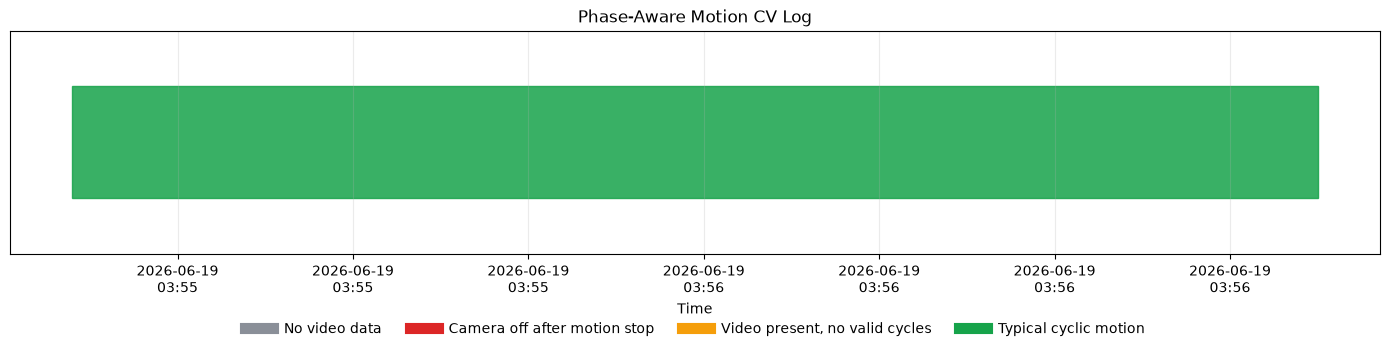

Timeline chart written to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\plots\cv_motion_log_timeline.png


In [21]:
def plot_cv_log_timeline(cv_log_df: pd.DataFrame, output_path: Path) -> None:
    """Plot one horizontal timeline of CV-log state intervals."""
    if cv_log_df.empty:
        print("No CV-log rows to plot.")
        return

    plot_df = cv_log_df.copy()
    plot_df["start_dt"] = pd.to_datetime(plot_df["start"], format="%Y-%m-%d_%H-%M-%S")
    plot_df["end_dt"] = pd.to_datetime(plot_df["end"], format="%Y-%m-%d_%H-%M-%S")

    state_colours = {
        "missing_video": "#8a8f98",
        "camera_off_after_motion_stop": "#dc2626",
        "present_no_valid_cycles": "#f59e0b",
        "typical_motion": "#16a34a",
    }

    fig, ax = plt.subplots(figsize=(14, 3.8))

    for _, row in plot_df.iterrows():
        colour = state_colours.get(row["state"], "#374151")
        ax.axvspan(row["start_dt"], row["end_dt"], ymin=0.25, ymax=0.75, color=colour, alpha=0.85)

    ax.set_yticks([])
    ax.set_title("Phase-Aware Motion CV Log")
    ax.set_xlabel("Time")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
    ax.grid(axis="x", alpha=0.25)

    handles = [
        plt.Line2D([0], [0], color="#8a8f98", lw=8, label="No video data"),
        plt.Line2D([0], [0], color="#dc2626", lw=8, label="Camera off after motion stop"),
        plt.Line2D([0], [0], color="#f59e0b", lw=8, label="Video present, no valid cycles"),
        plt.Line2D([0], [0], color="#16a34a", lw=8, label="Typical cyclic motion"),
    ]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)

    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()


timeline_plot_path = plot_dir / "cv_motion_log_timeline.png"
plot_cv_log_timeline(cv_log_df, timeline_plot_path)
print(f"Timeline chart written to: {timeline_plot_path}")


## 11. Local Summary Stats

In [22]:
summary_rows = []
for state, state_df in cv_log_df.groupby("state", dropna=False):
    duration_minutes = state_df["duration_s"].sum() / 60.0
    summary_rows.append({
        "state": state,
        "rows": len(state_df),
        "minutes": duration_minutes,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("state").reset_index(drop=True)
summary_path = output_dir / "cv_motion_log_summary.csv"
summary_df.to_csv(summary_path, index=False)

display(summary_df)
print(f"Summary written to: {summary_path}")


,state,rows,minutes
0,typical_motion,1,1.198022


Summary written to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\cv_motion_log_summary.csv


## 12. S3 Batch Settings

This uses the same Diageo S3 source as the other workflows, but delegates listing and chunked downloading to `VideoModule.parallel_io.s3_clip_source`. The reference phase profile from Section 6 is carried into each S3 row so actual production data can be compared with the expected cycle timing.


In [29]:
# Diageo camera source used by the other notebooks/scripts.
s3_aws_profile = "DashcamGlbDiageoProdDataContrib-522196013725"
s3_bucket = "diageo-prod-global-dashcam-mc-nuc-video"
s3_prefix = "cortexvpu-01a-005-41884872/"

# S3 time range. Use YYYY-MM-DD_HH-MM-SS.
s3_start_time = "2026-06-19_15-00-00"
s3_end_time = "2026-06-19_18-00-00"

# Runtime controls.
run_s3_pipeline = True
s3_max_clips_to_process = None # None means all clips in the time range.
s3_chunk_size = 2 # 
s3_keep_downloads = False
s3_skip_already_processed = True

# S3 output paths.
s3_context_clip_dir = s3_run_dir / "stoppage_context_clips"
s3_work_dir = s3_run_dir / "downloaded_videos"
s3_cv_log_path = s3_run_dir / "s3_cv_motion_log.csv"
s3_processed_videos_path = s3_run_dir / "s3_processed_videos.csv"
s3_summary_path = s3_run_dir / "s3_cv_motion_log_summary.csv"
s3_timeline_plot_path = s3_run_dir / "s3_cv_motion_log_timeline.png"

for s3_subdir in [s3_run_dir, s3_context_clip_dir, s3_work_dir]:
    s3_subdir.mkdir(parents=True, exist_ok=True)

print(f"S3 source: s3://{s3_bucket}/{s3_prefix}")
print(f"S3 range: {s3_start_time} to {s3_end_time}")
print(f"S3 outputs: {s3_run_dir}")


S3 source: s3://diageo-prod-global-dashcam-mc-nuc-video/cortexvpu-01a-005-41884872/
S3 range: 2026-06-19_15-00-00 to 2026-06-19_18-00-00
S3 outputs: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\s3_run


## 13. S3 Pipeline Run

The run order is:

1. List S3 clips in the requested timestamp range.
2. Download clips in small chunks.
3. Run the same phase-awareness CV-log processing as above.
4. Append the result row and mark the clip as processed.
5. Delete the downloaded video unless `s3_keep_downloads=True`.

S3 clips queued: 129
  Downloaded: 2 files
----------------------------------------------------
Processing S3 clip 1/129
  Local path: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\s3_run\downloaded_videos\cortexvpu-01a-005-41884872_2026-06-19_15-01-49_004271.ts
  Source: s3://diageo-prod-global-dashcam-mc-nuc-video/cortexvpu-01a-005-41884872/cortexvpu-01a-005-41884872_2026-06-19_15-01-49_004271.ts


C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\VideoModule\phase_detection\dynamic_phase_detection.py:1435: UserWarning: fCWT not available, using PyWavelets CWT (slower). For better performance, install fCWT: pip install fcwt
  span_regions, span_time, method = detect_frequency_regions_fcwt(


  Appended CV-log row to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\s3_run\s3_cv_motion_log.csv
  Marked processed in: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\s3_run\s3_processed_videos.csv
  Deleted downloaded video
----------------------------------------------------
Processing S3 clip 2/129
  Local path: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\s3_run\downloaded_videos\cortexvpu-01a-005-41884872_2026-06-19_15-03-04_400000.ts
  Source: s3://diageo-prod-global-dashcam-mc-nuc-video/cortexvpu-01a-005-41884872/cortexvpu-01a-005-41884872_2026-06-19_15-03-04_400000.ts


C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\VideoModule\phase_detection\dynamic_phase_detection.py:1435: UserWarning: fCWT not available, using PyWavelets CWT (slower). For better performance, install fCWT: pip install fcwt
  span_regions, span_time, method = detect_frequency_regions_fcwt(


  Appended CV-log row to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\s3_run\s3_cv_motion_log.csv
  Marked processed in: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\s3_run\s3_processed_videos.csv
  Deleted downloaded video
  Downloaded: 2 files
----------------------------------------------------
Processing S3 clip 3/129
  Local path: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\s3_run\downloaded_videos\cortexvpu-01a-005-41884872_2026-06-19_15-04-58_021450.ts
  Source: s3://diageo-prod-global-dashcam-mc-nuc-video/cortexvpu-01a-005-41884872/cortexvpu-01a-005-41884872_2026-06-19_15-04-58_021450.ts


...

C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\VideoModule\phase_detection\dynamic_phase_detection.py:1435: UserWarning: fCWT not available, using PyWavelets CWT (slower). For better performance, install fCWT: pip install fcwt
  span_regions, span_time, method = detect_frequency_regions_fcwt(


  Appended CV-log row to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\s3_run\s3_cv_motion_log.csv
  Marked processed in: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\s3_run\s3_processed_videos.csv
  Deleted downloaded video
  Downloaded: 1 files
----------------------------------------------------
Processing S3 clip 129/129
  Local path: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\s3_run\downloaded_videos\cortexvpu-01a-005-41884872_2026-06-19_17-45-04_933333.ts
  Source: s3://diageo-prod-global-dashcam-mc-nuc-video/cortexvpu-01a-005-41884872/cortexvpu-01a-005-41884872_2026-06-19_17-45-04_933333.ts


C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\VideoModule\phase_detection\dynamic_phase_detection.py:1435: UserWarning: fCWT not available, using PyWavelets CWT (slower). For better performance, install fCWT: pip install fcwt
  span_regions, span_time, method = detect_frequency_regions_fcwt(


  Appended CV-log row to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\s3_run\s3_cv_motion_log.csv
  Marked processed in: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\s3_run\s3_processed_videos.csv
  Deleted downloaded video


,state,rows,minutes
0,camera_off_after_motion_stop,1,855.366667
1,present_no_valid_cycles,20,20.209444
2,typical_motion,115,158.455556


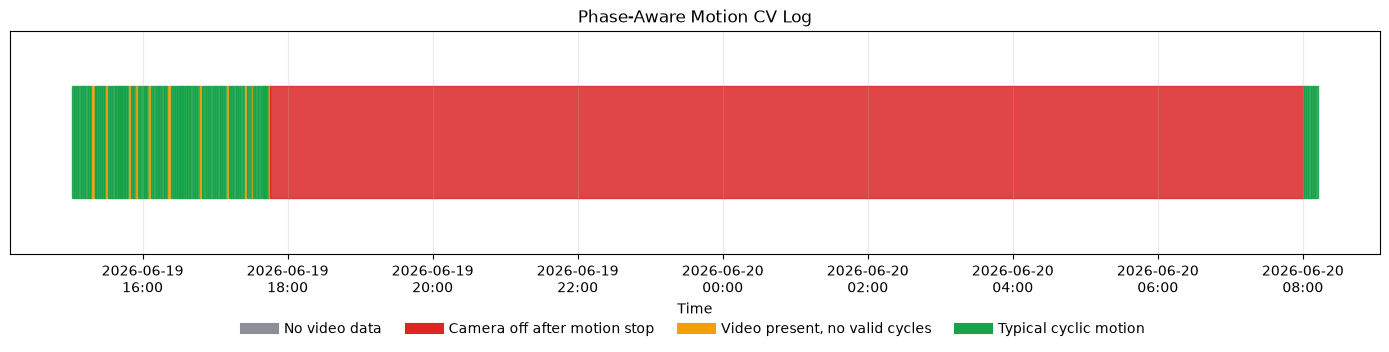

S3 summary written to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\s3_run\s3_cv_motion_log_summary.csv
S3 timeline written to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\video_coverage_log\phase_aware_motion_cv_log_output\s3_run\s3_cv_motion_log_timeline.png


In [30]:
def load_processed_s3_filenames(processed_videos_path: Path) -> set[str]:
    """Read the processed-video tracking file if it exists."""
    if not processed_videos_path.exists():
        return set()

    processed_df = pd.read_csv(processed_videos_path)
    if "filename" not in processed_df.columns:
        return set()

    return set(processed_df["filename"].dropna().astype(str))


def append_processed_s3_video(filename: str, source: str, processed_videos_path: Path) -> None:
    """Record one completed S3 video so reruns can skip it."""
    processed_row_df = pd.DataFrame([
        {
            "filename": filename,
            "source": source,
            "processed_at": pd.Timestamp.now().isoformat(),
        }
    ])

    if processed_videos_path.exists():
        existing_df = pd.read_csv(processed_videos_path)
        processed_df = pd.concat([existing_df, processed_row_df], ignore_index=True)
        processed_df = processed_df.drop_duplicates(subset=["filename"], keep="last")
    else:
        processed_df = processed_row_df

    processed_videos_path.parent.mkdir(parents=True, exist_ok=True)
    processed_df.to_csv(processed_videos_path, index=False)


def summarise_cv_log(cv_log_df: pd.DataFrame, summary_path: Path) -> pd.DataFrame:
    """Create the same state-duration summary for any CV-log dataframe."""
    summary_rows = []
    for state, state_df in cv_log_df.groupby("state", dropna=False):
        summary_rows.append({
            "state": state,
            "rows": len(state_df),
            "minutes": state_df["duration_s"].sum() / 60.0,
        })

    summary_df = pd.DataFrame(summary_rows).sort_values("state").reset_index(drop=True)
    summary_path.parent.mkdir(parents=True, exist_ok=True)
    summary_df.to_csv(summary_path, index=False)
    return summary_df


def list_diageo_s3_refs_to_process() -> list:
    """List Diageo S3 clips and apply direct-prefix, processed, and max-count filters."""
    from VideoModule.parallel_io.s3_clip_source import list_clips_in_range, parse_time_bound

    start_dt = parse_time_bound(s3_start_time)
    end_dt = parse_time_bound(s3_end_time, end=True)

    refs = list_clips_in_range(
        start=start_dt,
        end=end_dt,
        bucket=s3_bucket,
        prefix=s3_prefix,
        profile=s3_aws_profile,
        exts=(".ts",),
        max_clips=None,
    )

    # Match the existing Diageo scripts: skip generated outputs in nested folders under the same prefix.
    refs = [ref for ref in refs if ref.key == f"{s3_prefix}{Path(ref.key).name}"]

    if s3_skip_already_processed:
        processed_filenames = load_processed_s3_filenames(s3_processed_videos_path)
        refs = [ref for ref in refs if f"{ref.stem}.ts" not in processed_filenames]

    if s3_max_clips_to_process is not None:
        refs = refs[:s3_max_clips_to_process]

    return refs


if not run_s3_pipeline:
    print("S3 pipeline disabled. Set run_s3_pipeline=True to execute it.")
else:
    from VideoModule.parallel_io.s3_clip_source import stream_download_chunks

    s3_refs = list_diageo_s3_refs_to_process()
    print(f"S3 clips queued: {len(s3_refs)}")

    if not s3_refs:
        print("No S3 clips matched the current settings.")
    else:
        ref_by_stem = {ref.stem: ref for ref in s3_refs}
        processed_count = 0

        for chunk_paths in stream_download_chunks(
            s3_refs,
            s3_work_dir,
            chunk_size=s3_chunk_size,
            profile=s3_aws_profile,
        ):
            for local_video_path in chunk_paths:
                ref = ref_by_stem.get(local_video_path.stem)
                source = "" if ref is None else f"s3://{ref.bucket}/{ref.key}"
                processed_count += 1

                print("----------------------------------------------------")
                print(f"Processing S3 clip {processed_count}/{len(s3_refs)}")
                print(f"  Local path: {local_video_path}")
                print(f"  Source: {source}")

                try:
                    info = probe_video_safely(local_video_path)
                    interval_start = pd.Timestamp(ref.timestamp) if ref is not None else parse_video_start_time(local_video_path)
                    if interval_start is None:
                        interval_start = pd.Timestamp("1970-01-01 00:00:00")
                    interval_end = interval_start + pd.Timedelta(seconds=float(info.get("duration_s", 0.0) or 0.0))

                    row = build_cv_log_row_for_video(
                        video_path=local_video_path,
                        interval_start=interval_start,
                        interval_end=interval_end,
                        context_output_dir=s3_context_clip_dir,
                        source_label=source,
                        reference_phase_profile=reference_phase_profile,
                    )
                    row_df = pd.DataFrame([row])
                    append_dataframe_rows(row_df, s3_cv_log_path)
                    append_processed_s3_video(local_video_path.name, source, s3_processed_videos_path)

                    print(f"  Appended CV-log row to: {s3_cv_log_path}")
                    print(f"  Marked processed in: {s3_processed_videos_path}")

                except Exception as exc:
                    # Record failures as present-but-not-valid rows when the file was downloaded.
                    failure_start = pd.Timestamp(ref.timestamp) if ref is not None else pd.Timestamp("1970-01-01 00:00:00")
                    failure_row = {
                        "data_present": "y",
                        "start": format_log_time(failure_start),
                        "end": format_log_time(failure_start),
                        "valid_cycles": "n",
                        "state": "present_no_valid_cycles",
                        "video_name": local_video_path.name,
                        "video_path": str(local_video_path),
                        "source": source,
                        "status": "failed",
                        "reason": "processing failed",
                        "n_cycles": 0,
                        "cycle_frequency_hz": np.nan,
                        "mean_cycle_frames": np.nan,
                        "cycle_cv": np.nan,
                        **empty_reference_comparison(),
                        "duration_s": 0.0,
                        "fps": np.nan,
                        "n_frames": 0,
                        "detection_second": np.nan,
                        "stoppage_context_clip_path": "",
                        "phase_error": str(exc),
                        **empty_gap_context(),
                    }
                    append_dataframe_rows(pd.DataFrame([failure_row]), s3_cv_log_path)
                    append_processed_s3_video(local_video_path.name, source, s3_processed_videos_path)
                    print(f"  Failed and recorded: {exc}")

                finally:
                    # Keep disk bounded like the other S3 workflows.
                    if not s3_keep_downloads:
                        local_video_path.unlink(missing_ok=True)
                        print("  Deleted downloaded video")

        s3_cv_log_df = pd.read_csv(s3_cv_log_path)
        s3_analysis_end_time = None
        if s3_max_clips_to_process is None:
            from VideoModule.parallel_io.s3_clip_source import parse_time_bound
            s3_analysis_end_time = pd.Timestamp(parse_time_bound(s3_end_time, end=True))
        s3_cv_log_df = add_camera_off_gap_rows(s3_cv_log_df, s3_analysis_end_time)
        s3_cv_log_df.to_csv(s3_cv_log_path, index=False)
        s3_summary_df = summarise_cv_log(s3_cv_log_df, s3_summary_path)
        display(s3_summary_df)

        plot_cv_log_timeline(s3_cv_log_df, s3_timeline_plot_path)
        print(f"S3 summary written to: {s3_summary_path}")
        print(f"S3 timeline written to: {s3_timeline_plot_path}")
